# LABORATORIO SEMANA 5
Realizado por:

**- Ruelas Flores, César Diego**

## Parte A: Lectura de Datos, Preprocesamiento y Estadísticas Descriptivas

**Explicación:**

- Se importan las librerías necesarias.

- Se obtiene el dataset desde el repositorio UCI (utilizando la función fetch_ucirepo).

- Se combinan las características y la variable objetivo en un único DataFrame.

- Se eliminan duplicados y se corrigen posibles valores faltantes (se opta por eliminar filas incompletas, perotambien podrías usar imputación si quieres).

- Se calculan estadísticas descriptivas y se transforma la variable Class según la codificación (0 para benign y 1 para malignant).

- Se genera la matriz de correlación y se muestra mediante un heatmap.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")

### 1. Descarga y preparación de la base de datos

Obtener el dataset de cáncer de mama desde UCI Machine Learning Repository

In [34]:
from ucimlrepo import fetch_ucirepo 
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

Extraer características (X) y la variable objetivo (y)

In [35]:
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

In [36]:
# Combinar en un DataFrame
df = pd.concat([X, y], axis=1)

In [37]:
# Visualizar las primeras filas
display(df.head())

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


### 2. Preprocesamiento y análisis descriptivo

Eliminar duplicados

In [38]:
df.drop_duplicates(inplace=True)

Opcional: Verificar y eliminar valores faltantes (se pueden imputar según necesidad)

In [39]:
if df.isnull().sum().sum() > 0:
    print("Se encontraron valores faltantes. Se eliminarán las filas incompletas.")
    df.dropna(inplace=True)

Se encontraron valores faltantes. Se eliminarán las filas incompletas.


In [41]:
# Mostrar información y estadísticas básicas
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              449 non-null    int64  
 1   Uniformity_of_cell_size      449 non-null    int64  
 2   Uniformity_of_cell_shape     449 non-null    int64  
 3   Marginal_adhesion            449 non-null    int64  
 4   Single_epithelial_cell_size  449 non-null    int64  
 5   Bare_nuclei                  449 non-null    float64
 6   Bland_chromatin              449 non-null    int64  
 7   Normal_nucleoli              449 non-null    int64  
 8   Mitoses                      449 non-null    int64  
 9   Class                        449 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 38.6 KB


In [42]:
display(df.describe())

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,5.378619,4.222717,4.273942,3.746102,3.879733,4.806236,4.200445,3.828508,1.913140,3.051225
std,2.869029,3.251280,3.141494,3.158413,2.456544,3.880509,2.651634,3.387146,2.068909,0.999801
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,4.000000
75%,8.000000,7.000000,7.000000,6.000000,5.000000,10.000000,7.000000,7.000000,2.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


**Convertir la variable 'Class': 2 -> 0 (benign), 4 -> 1 (malignant)**

In [43]:
df['Class'] = df['Class'].apply(lambda x: 0 if x == 2 else 1 if x == 4 else x)
display(df['Class'].value_counts())

Class
1    236
0    213
Name: count, dtype: int64

### 3. Matriz de correlación y heatmap

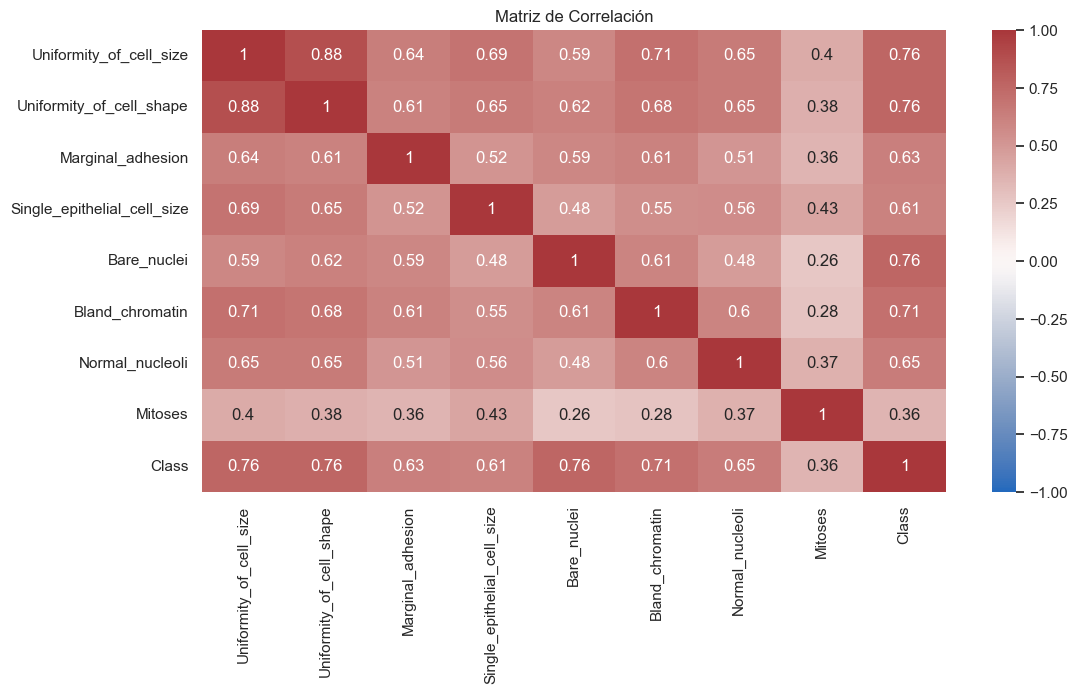

In [44]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:, 1:].corr(), annot=True, vmin=-1, vmax=1, cmap="vlag")
plt.title('Matriz de Correlación')
plt.show()

## Parte B: Visualización de Datos

### 1. Histogramas

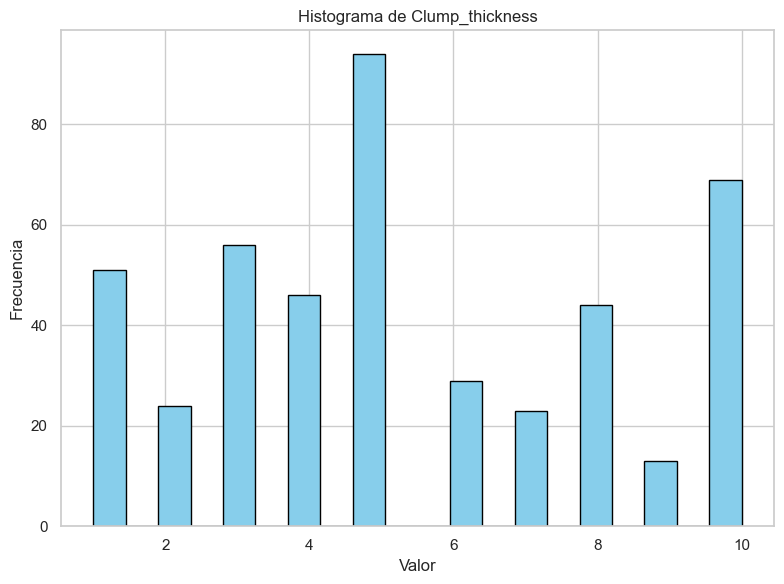

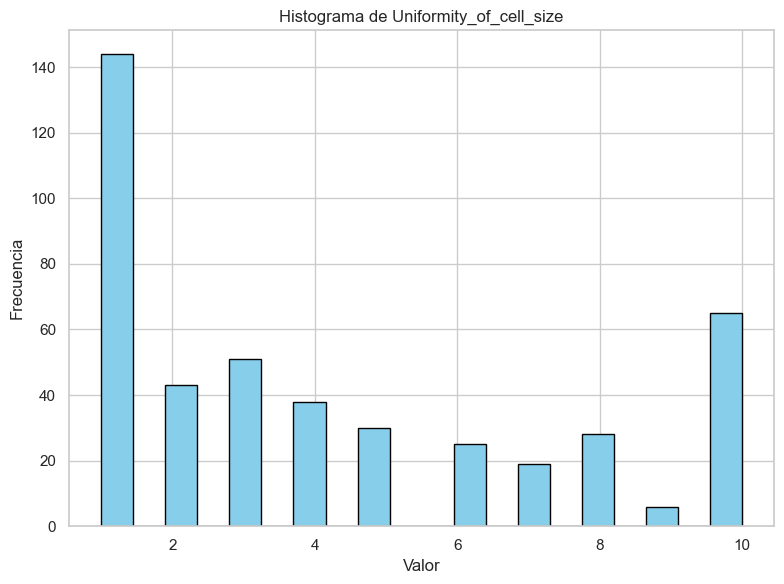

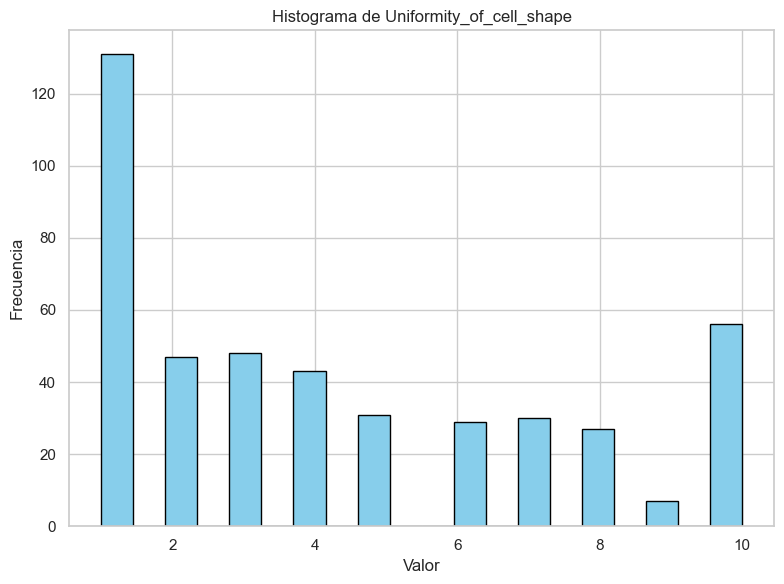

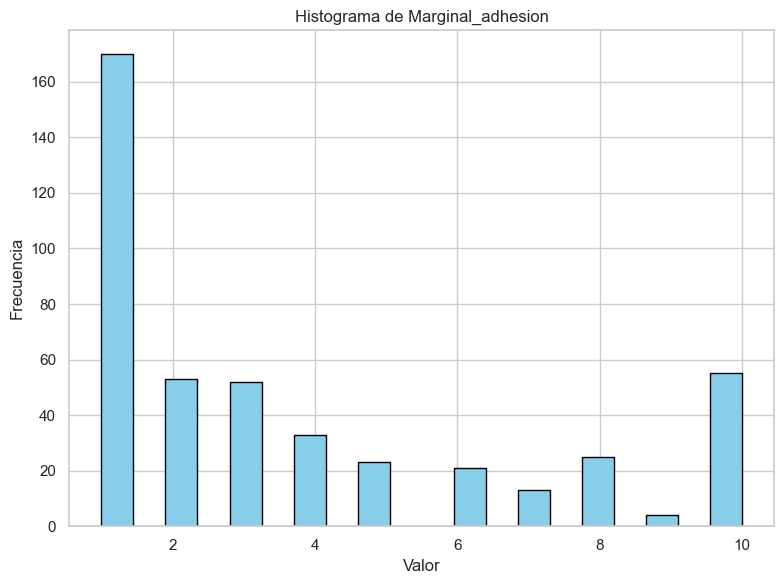

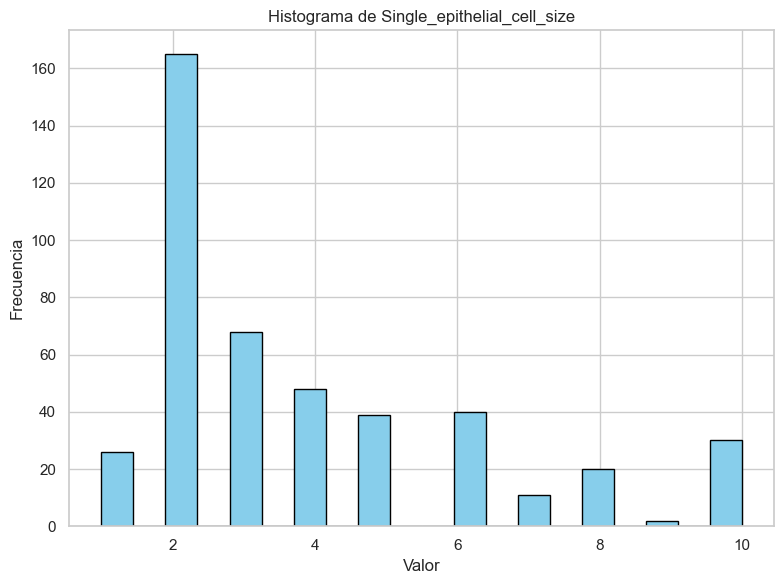

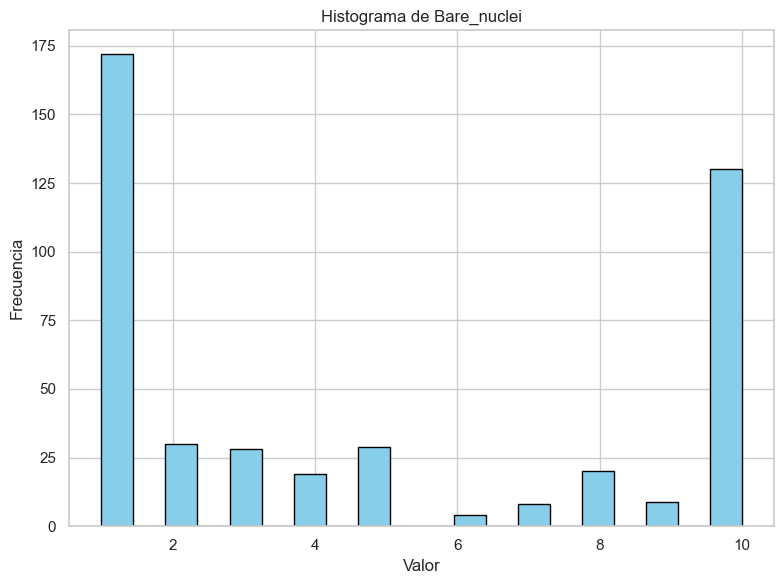

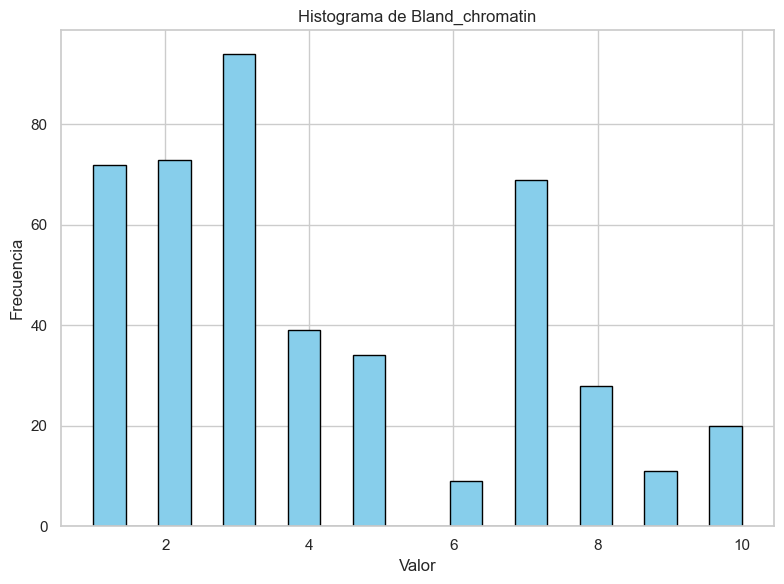

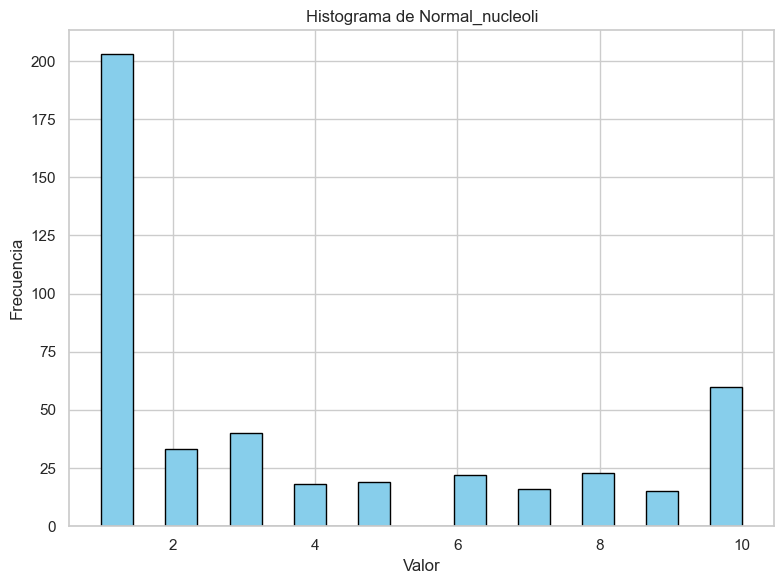

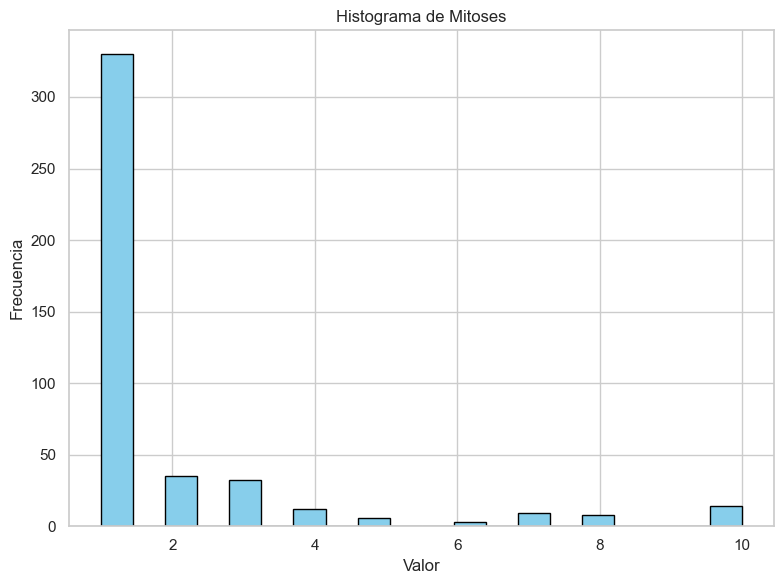

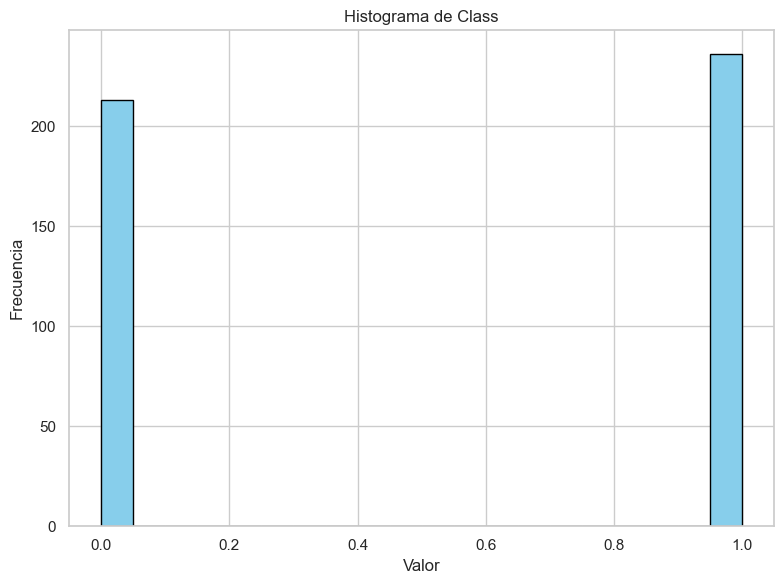

In [45]:
for col in df.columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histograma de {col}')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

### 2. Gráficos de densidad

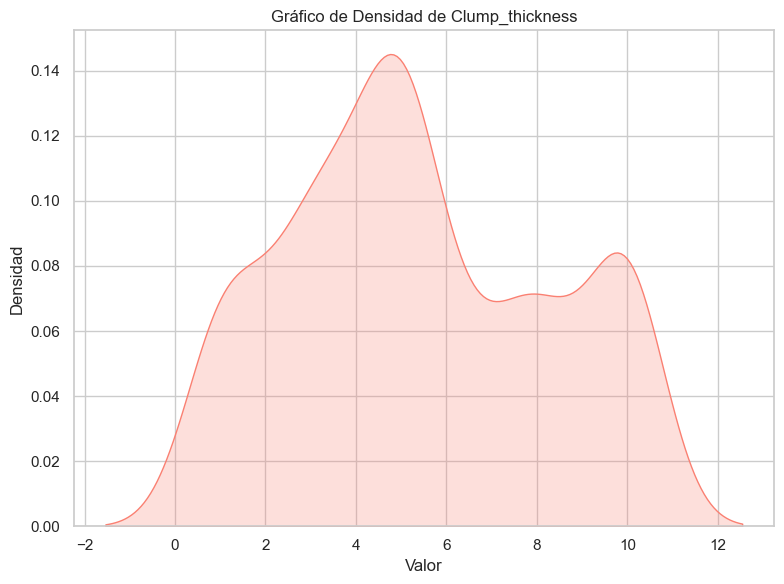

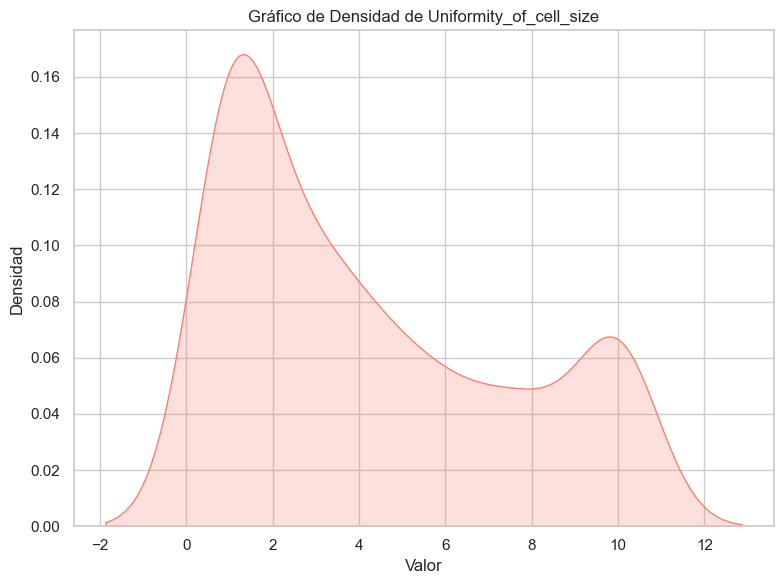

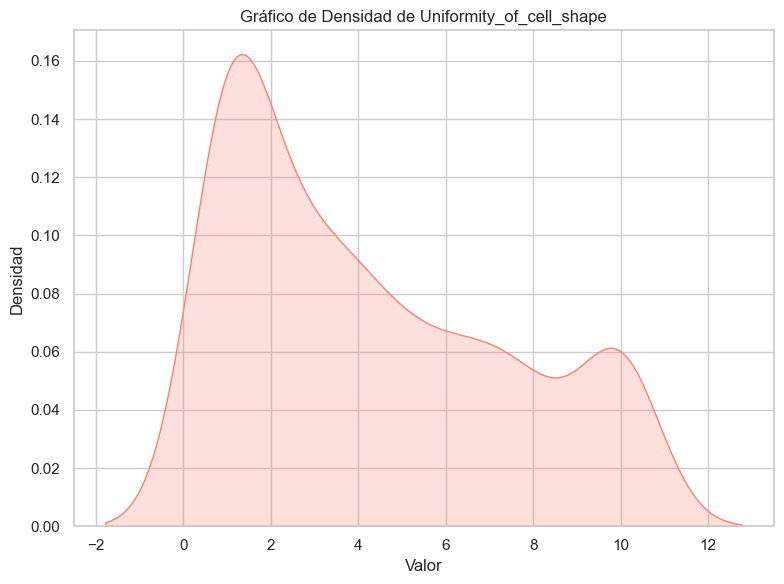

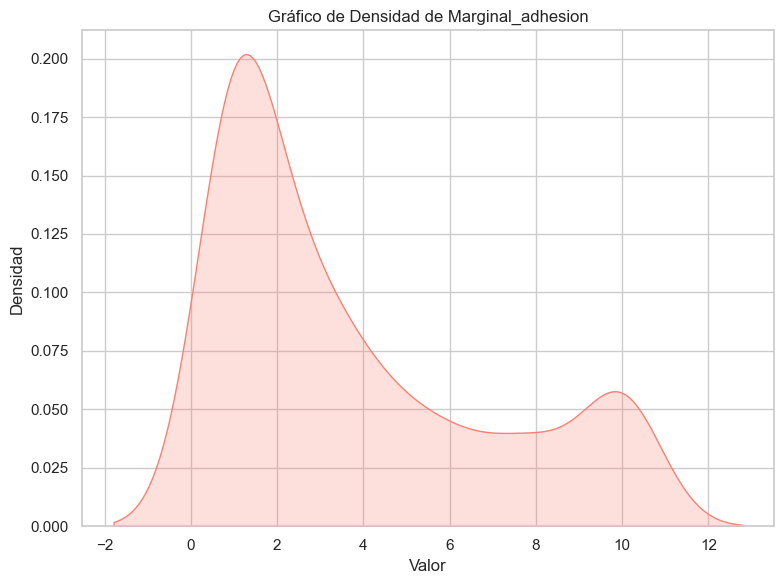

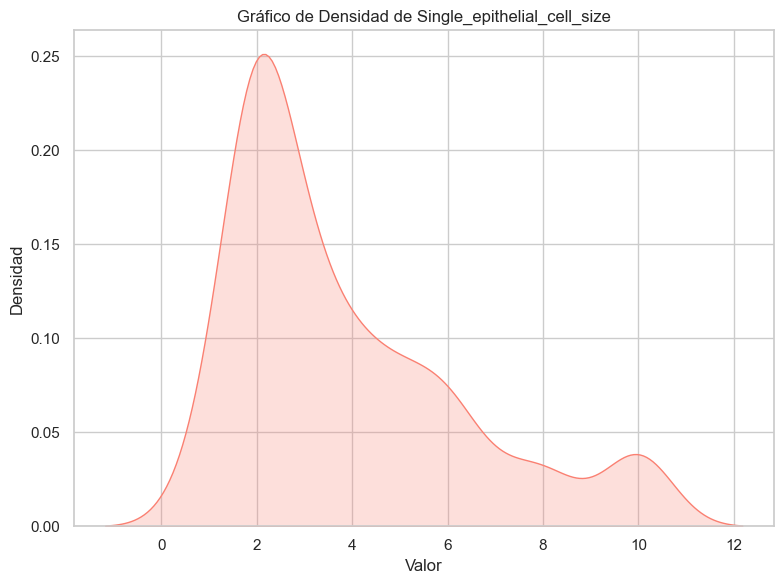

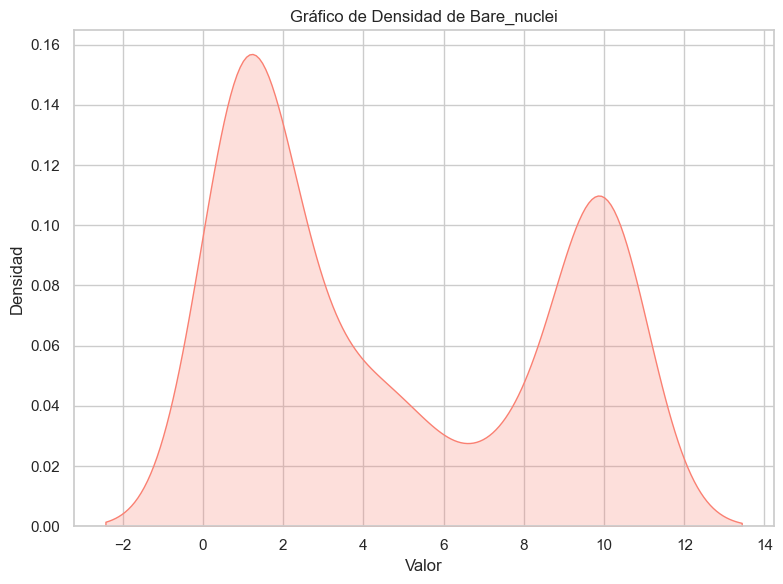

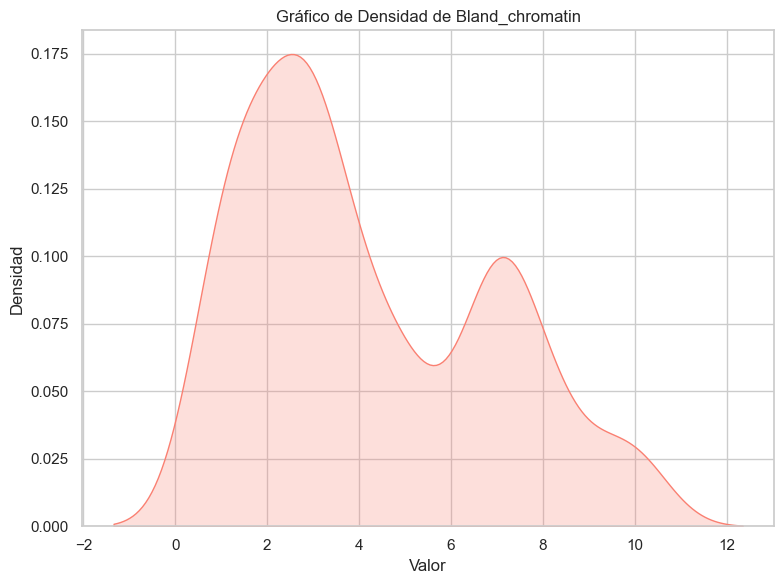

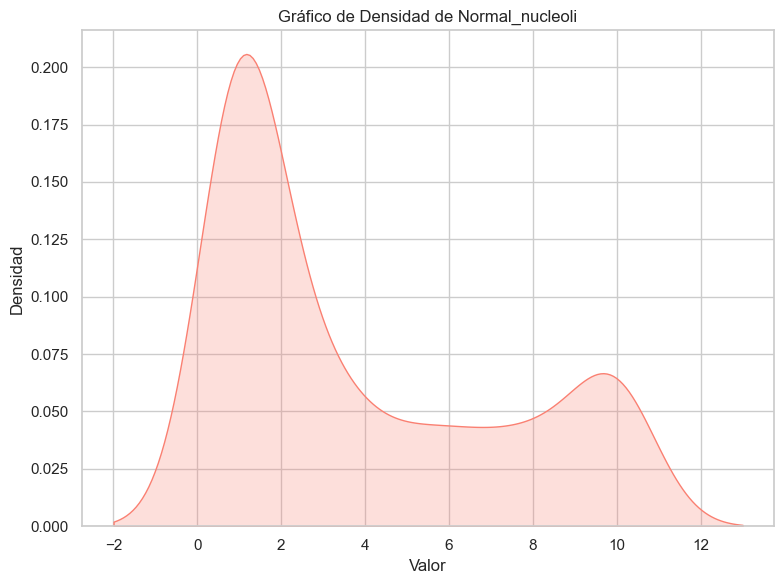

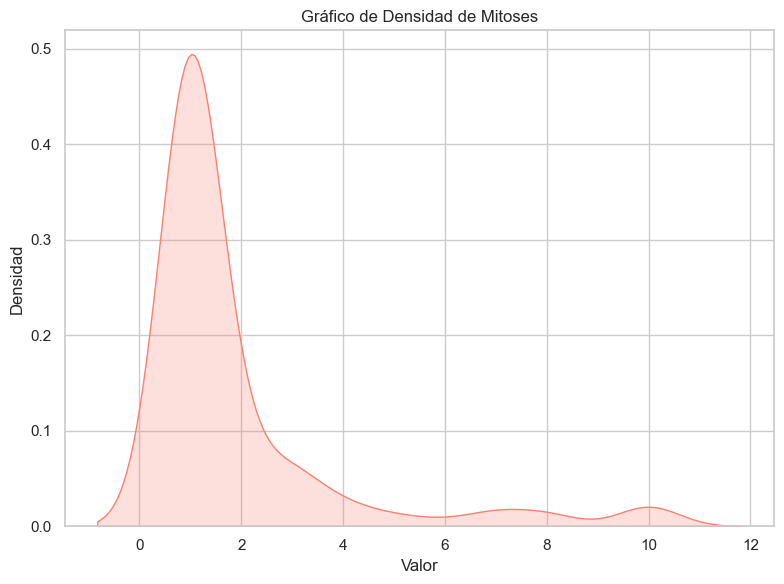

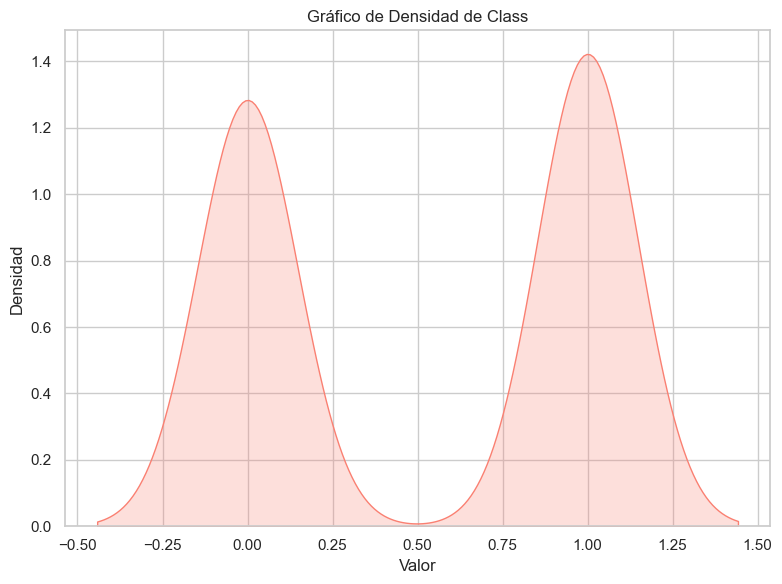

In [46]:
for col in df.columns:
    plt.figure(figsize=(8, 6))
    sns.kdeplot(data=df, x=col, color='salmon', fill=True)
    plt.title(f'Gráfico de Densidad de {col}')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

### 3. Box Plots para comparar variables según 'Class'

Configuración de subplots para box plots

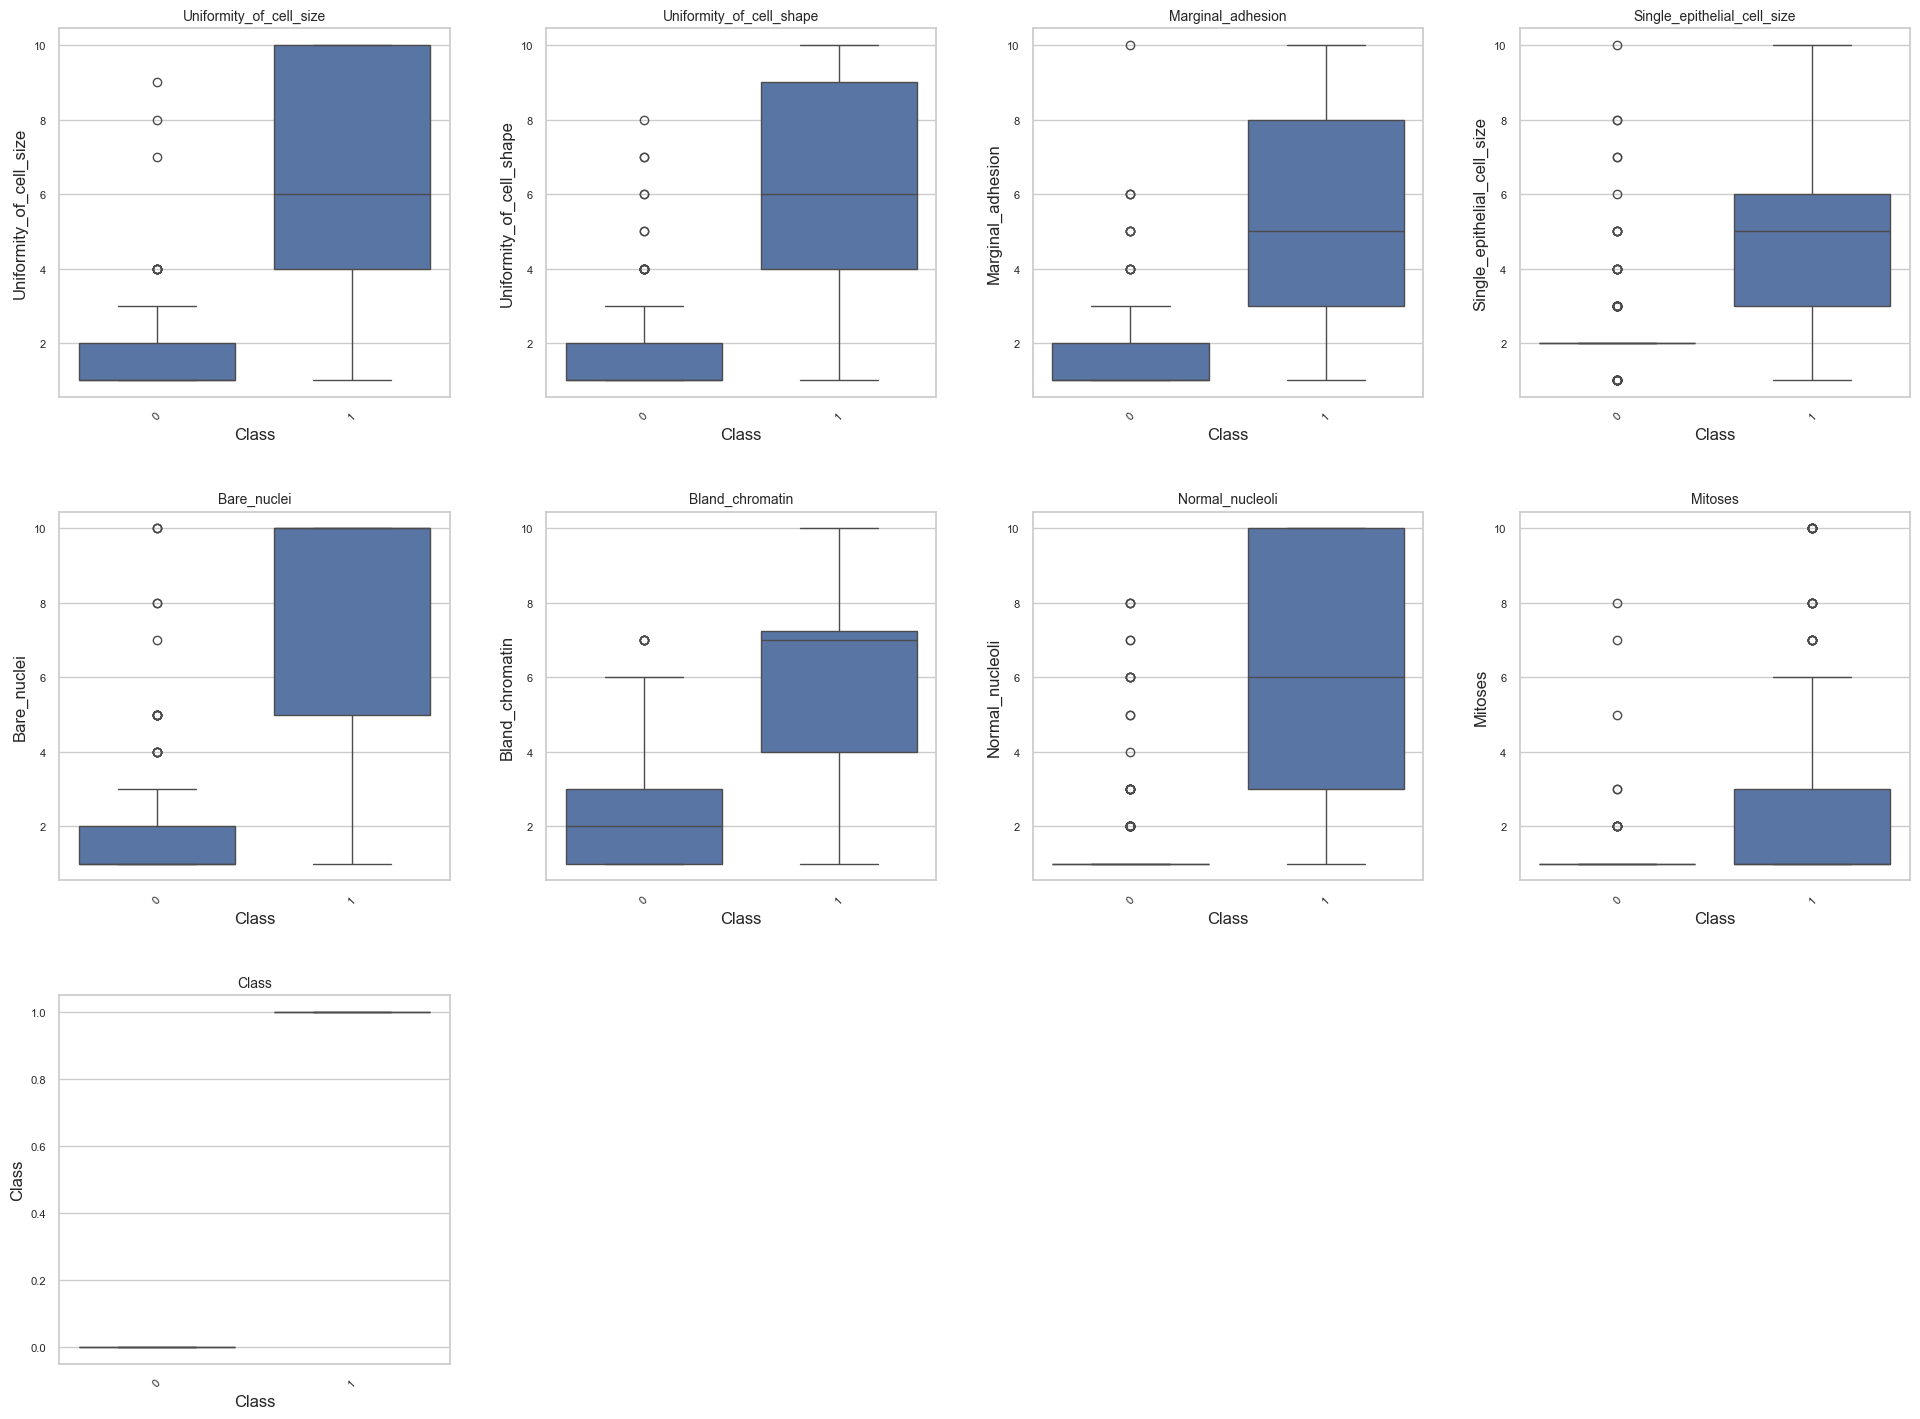

In [48]:
# Configuración de subplots para box plots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

# Asumimos que la primera columna es 'Class'. Se utilizan todas las demás.
for i, col in enumerate(df.columns[1:]):
    sns.boxplot(x='Class', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

# Ocultar ejes sobrantes si el número total de columnas es menor a 12
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()

## Parte C: Modelado con k-NN y Evaluación

En esta sección se realiza la implementación de un modelo de clasificación basado en el algoritmo k-NN (k-Nearest Neighbors). Se divide el conjunto de datos en conjuntos de entrenamiento y prueba, se entrena el modelo y se evalúa su desempeño mediante la métrica de precisión.

**Explicación:**

- Se separa el dataset en variables predictoras y la variable objetivo.

- Se divide la información en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba).

- Se implementa el modelo k-NN (con k=5), se entrena, y se realizan predicciones.

- Se mide la precisión del modelo en ambos conjuntos.

- Se han añadido consideraciones para evitar errores relacionados con valores NaN (ya aseguramos el preprocesamiento en la Parte A).

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

- train_test_split (sklearn.model_selection):

Esta función se utiliza para dividir el conjunto de datos en dos partes: una para entrenar el modelo y otra para probarlo. Esto permite evaluar el rendimiento del modelo en datos no vistos durante el entrenamiento, lo cual es esencial para medir la capacidad de generalización del modelo.

- KNeighborsClassifier (sklearn.neighbors):

Esta clase implementa el algoritmo k-NN. Este algoritmo es un método basado en instancias, donde la clasificación de un nuevo dato se realiza según la mayoría de las etiquetas (clasificación) de sus vecinos más cercanos. El parámetro n_neighbors (k) define cuántos vecinos se considerarán para tomar la decisión.

- accuracy_score (sklearn.metrics):

Esta función se utiliza para calcular la precisión del modelo, es decir, la proporción de predicciones correctas sobre el total de predicciones realizadas.

**Separar variables predictoras y la variable objetivo**

In [50]:
X = df.drop('Class', axis=1)
y = df['Class']

**Dividir en conjuntos de entrenamiento y prueba**

Se usa un 80% de los datos para entrenamiento y 20% para prueba.

El parámetro random_state=42 se utiliza para asegurar que la división sea reproducible.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Crear e implementar el modelo k-NN (k=5)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
# Entrenar (ajustar) el modelo usando el conjunto de entrenamiento
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Realizar predicciones en ambos conjuntos (entrenamiento y prueba)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

# Calcular la precisión (accuracy) del modelo en ambos conjuntos
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

# resultados de la precision
print(f'Precisión en entrenamiento: {accuracy_train:.4f}')
print(f'Precisión en prueba: {accuracy_test:.4f}')

Precisión en entrenamiento: 0.9721
Precisión en prueba: 0.9556
